In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set up visualization settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
# Load the CSV file
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f"Dataset loaded! Shape: {df.shape}")
print(f"  - Rows: {df.shape[0]} (customers)")
print(f"  - Columns: {df.shape[1]} (features)")

Dataset loaded! Shape: (7043, 21)
  - Rows: 7043 (customers)
  - Columns: 21 (features)


In [4]:
# Display first 5 rows
print("First 5 rows of data:")
print(df.head())

First 5 rows of data:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovie

In [5]:
# Detailed info about each column
print("Data types and missing values:")
df.info()


Data types and missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBi

In [6]:
# Statistics for numerical columns
print("Statistical summary of numerical columns:")
print(df.describe())

Statistical summary of numerical columns:
       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


In [9]:
# Check target variable
print("Target variable distribution:")
print(df['Churn'].value_counts())
print("\nPercentage:")
print(df['Churn'].value_counts(normalize=True) * 100)

Target variable distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


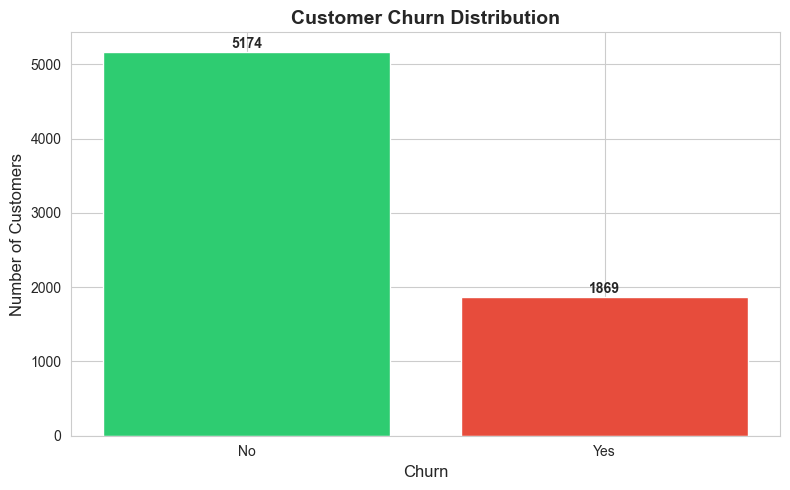

In [10]:
# Visualize churn distribution
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

churn_counts = df['Churn'].value_counts()
colors = ['#2ecc71', '#e74c3c']  # Green for No, Red for Yes

ax.bar(churn_counts.index, churn_counts.values, color=colors)
ax.set_ylabel('Number of Customers', fontsize=12)
ax.set_xlabel('Churn', fontsize=12)
ax.set_title('Customer Churn Distribution', fontsize=14, fontweight='bold')

# Add count labels on bars
for i, v in enumerate(churn_counts.values):
    ax.text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [11]:
# Show all column names
print("All columns in dataset:")
print(df.columns.tolist())

All columns in dataset:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [12]:
# Look at categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns: {categorical_cols}")
print(f"\nNumber of categorical columns: {len(categorical_cols)}")

# Show unique values for each categorical column
print("\n" + "="*60)
for col in categorical_cols:
    unique_count = df[col].nunique()
    print(f"\n{col} ({unique_count} unique values):")
    print(f"  {df[col].unique()[:10]}")  # Show first 10 unique values

Categorical columns: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']

Number of categorical columns: 18


customerID (7043 unique values):
  ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' '7795-CFOCW' '9237-HQITU'
 '9305-CDSKC' '1452-KIOVK' '6713-OKOMC' '7892-POOKP' '6388-TABGU']

gender (2 unique values):
  ['Female' 'Male']

Partner (2 unique values):
  ['Yes' 'No']

Dependents (2 unique values):
  ['No' 'Yes']

PhoneService (2 unique values):
  ['No' 'Yes']

MultipleLines (3 unique values):
  ['No phone service' 'No' 'Yes']

InternetService (3 unique values):
  ['DSL' 'Fiber optic' 'No']

OnlineSecurity (3 unique values):
  ['No' 'Yes' 'No internet service']

OnlineBackup (3 unique values):
  ['Yes' 'No' 'No internet service']

DeviceProtection (3 unique values):

In [13]:
# Check for missing values
print("Missing values:")
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing_Count': missing.values,
    'Percentage': missing_percent.values
})

missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_df) == 0:
    print("✅ No missing values! Data is clean.")
else:
    print(missing_df)

Missing values:
✅ No missing values! Data is clean.


In [23]:
# Select numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Add target column if not included
if 'Churn' not in numerical_cols:
    numerical_cols.append('Churn')

print(f"Numerical columns: {numerical_cols}\n")

# Calculate correlations
correlation = df[numerical_cols].corr()['Churn'].sort_values(ascending=False)

print("Correlation with Churn (target):")
print(correlation)

Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'Churn']

Correlation with Churn (target):
Churn             1.000000
MonthlyCharges    0.193356
SeniorCitizen     0.150889
tenure           -0.352229
Name: Churn, dtype: float64


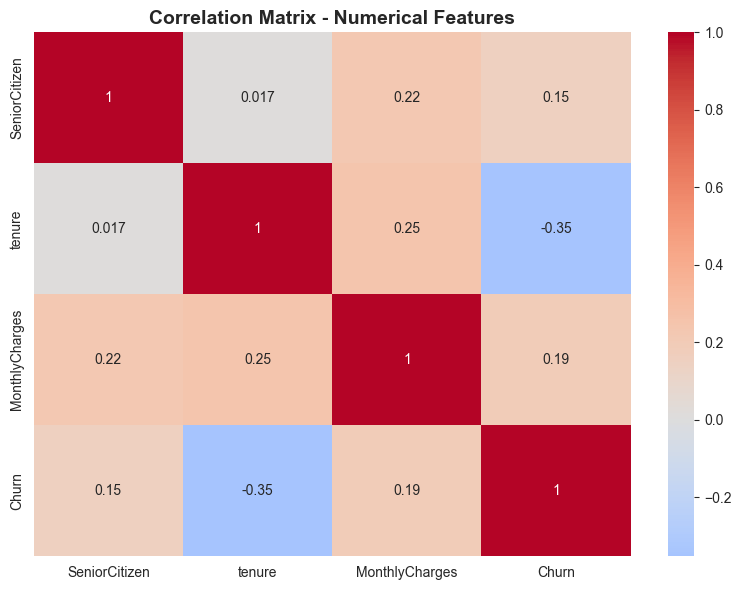

In [24]:
# Create correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix - Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

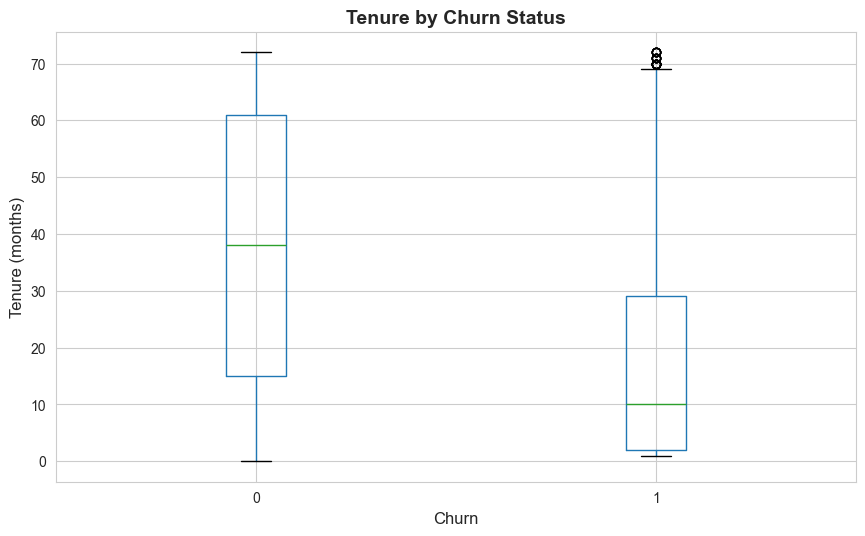

In [26]:
# Visualize relationship between tenure and churn
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Create box plot
df.boxplot(column='tenure', by='Churn', ax=ax)

ax.set_xlabel('Churn', fontsize=12)
ax.set_ylabel('Tenure (months)', fontsize=12)
ax.set_title('Tenure by Churn Status', fontsize=14, fontweight='bold')

plt.suptitle('')
plt.show()

In [29]:
# Summary of EDA findings
print("="*70)
print("EXPLORATORY DATA ANALYSIS - KEY FINDINGS")
print("="*70)
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f"\n1. DATASET SIZE")
print(f"   - Total customers: {len(df):,}")
print(f"   - Total features: {df.shape[1]}")

print(f"\n2. TARGET VARIABLE (Churn)")
churn_counts = df['Churn'].value_counts()
print(f"   - No (retained): {churn_counts['No']:,} ({churn_counts['No']/len(df)*100:.1f}%)")
print(f"   - Yes (churned): {churn_counts['Yes']:,} ({churn_counts['Yes']/len(df)*100:.1f}%)")
print(f"   - Imbalance ratio: {churn_counts['No']/churn_counts['Yes']:.2f}:1")

print(f"\n3. DATA QUALITY")
print(f"   - Missing values: {df.isnull().sum().sum()} ✅ (clean!)")
print(f"   - Duplicate rows: {df.duplicated().sum()} ✅ (clean!)")

print(f"\n4. FEATURE TYPES")
print(f"   - Numerical features: {len(df.select_dtypes(include=['int64', 'float64']).columns)}")
print(f"   - Categorical features: {len(df.select_dtypes(include='object').columns)}")

print(f"\n5. KEY INSIGHTS")
print(f"   - Customers who churn have LOWER tenure (17.98 vs 37.57 months)")
print(f"   - Higher monthly charges slightly increase churn likelihood")
print(f"   - Senior citizens have slightly higher churn rates")

print("\n" + "="*70)

EXPLORATORY DATA ANALYSIS - KEY FINDINGS

1. DATASET SIZE
   - Total customers: 7,043
   - Total features: 21

2. TARGET VARIABLE (Churn)
   - No (retained): 5,174 (73.5%)
   - Yes (churned): 1,869 (26.5%)
   - Imbalance ratio: 2.77:1

3. DATA QUALITY
   - Missing values: 0 ✅ (clean!)
   - Duplicate rows: 0 ✅ (clean!)

4. FEATURE TYPES
   - Numerical features: 3
   - Categorical features: 18

5. KEY INSIGHTS
   - Customers who churn have LOWER tenure (17.98 vs 37.57 months)
   - Higher monthly charges slightly increase churn likelihood
   - Senior citizens have slightly higher churn rates



In [30]:
# Save summary to file
summary = """
CHURN PREDICTION - DATA SUMMARY
================================

Dataset: Telco Customer Churn
Source: Kaggle
Records: 7,043 customers
Features: 21 columns

TARGET: Churn (Yes/No)
- No: 5,174 customers (73.5%)
- Yes: 1,869 customers (26.5%)
- Class imbalance: 2.76:1

KEY FINDINGS:
1. No missing values - data is clean
2. Tenure is strongest predictor (r=-0.35)
3. Customers who churn leave within 17.98 months avg
4. Customers who stay average 37.57 months
5. Higher monthly charges correlate with more churn

NEXT STEPS:
- Step 4: Data cleaning & feature engineering
- Step 5: Train baseline models
- Step 6: Hyperparameter tuning
"""

# Write to file
with open('../data/processed/data_summary.txt', 'w') as f:
    f.write(summary)

print("✅ Summary saved to data_summary.txt")

✅ Summary saved to data_summary.txt
